# Modelling

### Membaca Sequence Dataset Suku Kata

In [1]:
import pandas as pd

# =========================================================
# 1. MEMBACA DATASET SEQUENCE SUKU KATA
# =========================================================
print(" [PROSES] Membaca file dataset...")
df_nlp = pd.read_csv("1_dataset_rnn/final_dataset.csv")

print("\n" + "="*50)
print("=== INFORMASI DATASET SEQUENCE ===")
print("="*50)
print(df_nlp.head())

print("\n Jumlah Baris Dataset:", len(df_nlp))
print(" [STATUS] Cell 1 Selesai Tanpa Error.")

 [PROSES] Membaca file dataset...

=== INFORMASI DATASET SEQUENCE ===
  Input_Suku_Kata Target_Kata_Utuh
0         a ba di            abadi
1           a bai             abai
2          a bang            abang
3            abdi             abdi
4           abjad            abjad

 Jumlah Baris Dataset: 1864
 [STATUS] Cell 1 Selesai Tanpa Error.


### Ekstraksi Kata dan Tokenisasi Input

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np

# =========================================================
# 2. AMBIL DATA INPUT & TARGET RAW
# =========================================================
X_raw = df_nlp["Input_Suku_Kata"].astype(str).values
Y_raw = df_nlp["Target_Kata_Utuh"].astype(str).values

print(" [PROSES] Memeriksa data kosong...")
print(f"   -> X Kosong: {np.sum(pd.isna(X_raw))} baris")
print(f"   -> Y Kosong: {np.sum(pd.isna(Y_raw))} baris\n")

# =========================================================
# 3. TOKENISASI DATA INPUT (X)
# =========================================================
print(" [PROSES] Membangun Tokenizer untuk Input (X)...")
tokenizer = Tokenizer(filters='', lower=True, oov_token="<OOV>")
tokenizer.fit_on_texts(X_raw)

# Konversi teks suku kata menjadi sequence angka
X_sequences = tokenizer.texts_to_sequences(X_raw)

print("\n" + "="*50)
print("=== INFO VOCABULARY INPUT (X) ===")
print("="*50)
print(" Total Vocabulary Input:", len(tokenizer.word_index))
print(" Sampel Word Index (10 Teratas):")
print(list(tokenizer.word_index.items())[:10])

print("\n [CONTOH TRANSFORMASI INPUT]")
print("   -> Raw Teks :", X_raw[0])
print("   -> Sequence :", X_sequences[0])
print("\n [STATUS] Cell 2 Selesai Tanpa Error.")

I0000 00:00:1785882012.422408    7778 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785882012.438506    7778 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785882014.073985    7778 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785882017.076982    7778 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

 [PROSES] Memeriksa data kosong...
   -> X Kosong: 0 baris
   -> Y Kosong: 0 baris

 [PROSES] Membangun Tokenizer untuk Input (X)...

=== INFO VOCABULARY INPUT (X) ===
🔹 Total Vocabulary Input: 929
🔹 Sampel Word Index (10 Teratas):
[('<OOV>', 1), ('ba', 2), ('da', 3), ('ka', 4), ('ra', 5), ('la', 6), ('ga', 7), ('ja', 8), ('ta', 9), ('ha', 10)]

 [CONTOH TRANSFORMASI INPUT]
   -> Raw Teks : a ba di
   -> Sequence : [22, 2, 27]

 [STATUS] Cell 2 Selesai Tanpa Error.


### Transformasi Target Suku Kata

In [ ]:
# =========================================================
# 4. MEMBANGUN TARGET CHARACTER SEQUENCE (Y_char)
# =========================================================
print(" [PROSES] Memecah kata target menjadi rangkaian karakter...")
Y_char = []

for kata in Y_raw:
    # Mengubah "buku" menjadi "b u k u"
    karakter = " ".join(list(kata))
    Y_char.append(karakter)

print("\n" + "="*50)
print("=== HASIL TRANSFORMASI KARAKTER TARGET ===")
print("="*50)
for i in range(3):
    print(f"   [{i+1}] Kata Asli: {Y_raw[i]}  Char Target: '{Y_char[i]}'")

print("\n [STATUS] Cell 3 Selesai Tanpa Error.")

✂️ [PROSES] Memecah kata target menjadi rangkaian karakter...

=== HASIL TRANSFORMASI KARAKTER TARGET ===
   [1] Kata Asli: abadi ➡️ Char Target: 'a b a d i'
   [2] Kata Asli: abai ➡️ Char Target: 'a b a i'
   [3] Kata Asli: abang ➡️ Char Target: 'a b a n g'

 [STATUS] Cell 3 Selesai Tanpa Error.


### Tokenisasi Data Target

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# =========================================================
# 5. TOKENISASI DATA TARGET (Y) - VERSI BENAR & SINKRON
# =========================================================
print(" [PROSES] Membangun Tokenizer untuk Target (Y)...")

target_tokenizer = Tokenizer(
    filters='', 
    lower=True, 
    char_level=True  # Membaca per huruf tunggal secara otomatis
)

# KUNCI PERBAIKAN: Langsung membaca dari Y_raw (kata utuh rapat tanpa spasi manual)
target_tokenizer.fit_on_texts(Y_raw)

# Konversi kata utuh menjadi sequence angka token huruf alfabet murni
Y_sequences = target_tokenizer.texts_to_sequences(Y_raw)

print("\n" + "="*50)
print("=== INFO VOCABULARY TARGET (Y) MURNI ===")
print("="*50)
# Sekarang jumlah vocabulary akan sangat kecil (hanya huruf alfabet saja, TANPA spasi)
print(" Total Vocabulary Karakter Target :", len(target_tokenizer.word_index))
print(" Kamus Huruf Target yang Terbentuk:")
print(target_tokenizer.word_index)

print("\n [CONTOH TRANSFORMASI TARGET BARU]")
print("   -> Target Awal :", Y_raw[0])
print("   -> Hasil Token :", Y_sequences[0])
print("\n [STATUS] Cell 4 Selesai & Berhasil Diperbaiki tanpa NameError!")

 [PROSES] Membangun Tokenizer untuk Target (Y)...

=== INFO VOCABULARY TARGET (Y) MURNI ===
🔸 Total Vocabulary Karakter Target : 26
🔸 Kamus Huruf Target yang Terbentuk:
{'a': 1, 'i': 2, 'n': 3, 'b': 4, 'k': 5, 'd': 6, 'r': 7, 'l': 8, 's': 9, 'u': 10, 'g': 11, 't': 12, 'h': 13, 'e': 14, 'm': 15, 'o': 16, 'f': 17, 'c': 18, 'j': 19, 'p': 20, 'y': 21, 'w': 22, 'z': 23, 'v': 24, 'q': 25, 'x': 26}

 [CONTOH TRANSFORMASI TARGET BARU]
   -> Target Awal : abadi
   -> Hasil Token : [1, 4, 1, 6, 2]

 [STATUS] Cell 4 Selesai & Berhasil Diperbaiki tanpa NameError!


### Sinkronisasi Padding Global

In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =========================================================
# 6. MENCARI PANJANG MAKSIMUM GLOBAL
# =========================================================
print(" [PROSES] Menghitung panjang maksimum global untuk sinkronisasi...")
max_len = max(
    max(len(seq) for seq in X_sequences),
    max(len(seq) for seq in Y_sequences)
)

print(f"   -> Panjang Maksimum Global Terpilih: {max_len} timestep\n")

# =========================================================
# 7. PROSES PADDING SERENTAK
# =========================================================
print(" [PROSES] Melakukan post-padding pada X_sequences & Y_sequences...")
X_padded = pad_sequences(X_sequences, maxlen=max_len, padding='post')
Y_padded = pad_sequences(Y_sequences, maxlen=max_len, padding='post')

print("\n" + "="*50)
print("=== MATRIKS HASIL PADDING DIMENSI GLOBAL ===")
print("="*50)
print(" Shape X Padded (Input)  :", X_padded.shape)
print(" Shape Y Padded (Target) :", Y_padded.shape)

print("\n [CONTOH DATA SETELAH PADDING]")
print("   -> Matriks X[0] :", X_padded[0])
print("   -> Matriks Y[0] :", Y_padded[0])
print("\n [STATUS] Cell 5 Selesai Tanpa Error.")

 [PROSES] Menghitung panjang maksimum global untuk sinkronisasi...
   -> Panjang Maksimum Global Terpilih: 12 timestep

 [PROSES] Melakukan post-padding pada X_sequences & Y_sequences...

=== MATRIKS HASIL PADDING DIMENSI GLOBAL ===
 Shape X Padded (Input)  : (1864, 12)
 Shape Y Padded (Target) : (1864, 12)

 [CONTOH DATA SETELAH PADDING]
   -> Matriks X[0] : [22  2 27  0  0  0  0  0  0  0  0  0]
   -> Matriks Y[0] : [1 4 1 6 2 0 0 0 0 0 0 0]

 [STATUS] Cell 5 Selesai Tanpa Error.


### Validasi Struktur Data

In [6]:
print(" [PROSES] Memvalidasi keselarasan struktur data...")

# Verifikasi akhir untuk memastikan dimensi baris dan kolom sama kuat
if X_padded.shape == Y_padded.shape:
    print("\n [AMAN] Dimensi Input (X) dan Target (Y) SANGAT SINKRON!")
    print(f"   Kedua data siap masuk ke arsitektur Many-to-Many dengan dimensi: {X_padded.shape}")
else:
    print("\n [PERINGATAN] Ada ketidakcocokan dimensi, periksa kembali!")

print("\n [STATUS] Cell 6 Selesai Tanpa Error.")

 [PROSES] Memvalidasi keselarasan struktur data...

 [AMAN] Dimensi Input (X) dan Target (Y) SANGAT SINKRON!
   Kedua data siap masuk ke arsitektur Many-to-Many dengan dimensi: (1864, 12)

 [STATUS] Cell 6 Selesai Tanpa Error.


### Split Data dan Validation

In [7]:
from sklearn.model_selection import train_test_split

# =========================================================
# 8. MEMBAGI DATA TRAINING DAN VALIDATION (80:20)
# =========================================================
print(" [PROSES] Memecah data menjadi porsi Train dan Validation...")
X_train, X_val, Y_train, Y_val = train_test_split(
    X_padded,
    Y_padded,
    test_size=0.2,
    random_state=42
)

print("\n" + "="*50)
print("=== DISTRIBUSI DIMENSI DATA SPLIT ===")
print("="*50)
print(f" [TRAIN]      Shape X: {X_train.shape}  |  Shape Y: {Y_train.shape}")
print(f" [VALIDATION] Shape X: {X_val.shape}  |  Shape Y: {Y_val.shape}")

print("\n [STATUS] Cell 7 Selesai Tanpa Error.")

 [PROSES] Memecah data menjadi porsi Train dan Validation...

=== DISTRIBUSI DIMENSI DATA SPLIT ===
 [TRAIN]      Shape X: (1491, 12)  |  Shape Y: (1491, 12)
 [VALIDATION] Shape X: (373, 12)  |  Shape Y: (373, 12)

 [STATUS] Cell 7 Selesai Tanpa Error.


### Membangun dan Kompilasi Arsitektur RNN

In [8]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, TimeDistributed, RepeatVector, Bidirectional, Dropout

# =========================================================
# LANGKAH 1: JALUR PENYELAMATAN SEED BARU (MENGHINDARI MACET)
# =========================================================
# Kita ganti dari 42 ke 100 untuk membuka peta bobot awal yang berbeda
NILAI_SEED = 100

os.environ['PYTHONHASHSEED'] = str(NILAI_SEED)
tf.random.set_seed(NILAI_SEED)
np.random.seed(NILAI_SEED)
random.seed(NILAI_SEED)
print(f" [SISTEM] Random seed berhasil dikunci secara ketat pada angka {NILAI_SEED}.")

# =========================================================
# 9. MENENTUKAN UKURAN VOCABULARY (+1 UNTUK PADDING TOKEN 0)
# =========================================================
input_vocab_size = len(tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

print(" [PROSES] Merakit ARSITEKTUR REVISI: Seq2Seq Optimasi Eksperimen...")

# =========================================================
# 10. MEMBANGUN MODEL ENCODER-DECODER (DROPOUT RINGAN 10%)
# =========================================================
text_model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=input_vocab_size, output_dim=128, mask_zero=True),
    
    # Encoder LSTM dua arah
    Bidirectional(LSTM(128, return_sequences=False)), 
    Dropout(0.1), # Diturunkan ke 10% agar model tidak kehilangan memori penting
    
    # Jembatan Dimensi
    RepeatVector(max_len),
    
    # Decoder LSTM 256 Neuron
    LSTM(256, return_sequences=True),
    Dropout(0.1), # Diturunkan ke 10%
    
    TimeDistributed(Dense(target_vocab_size, activation='softmax'))
])

# =========================================================
# 11. COMPILE MODEL
# =========================================================
text_model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*50)
print("=== RINGKASAN ARSITEKTUR OPTIMASI EKSPERIMEN ===")
print("="*50)
text_model.summary()

print("\n [SUKSES] Model siap dilatih kembali dengan rute inisialisasi baru!")

 [SISTEM] Random seed berhasil dikunci secara ketat pada angka 100.
 [PROSES] Merakit ARSITEKTUR REVISI: Seq2Seq Optimasi Eksperimen...


E0000 00:00:1785882020.254345    7778 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected



=== RINGKASAN ARSITEKTUR OPTIMASI EKSPERIMEN ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 12, 128)        │       119,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 12, 27)         │         6,939 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 914,459 (3.49 MB)

 Trainable params: 914,459 (3.49 MB)

 Non-trainable params: 0 (0.00 B)


 [SUKSES] Model siap dilatih kembali dengan rute inisialisasi baru!


### Model Training

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# =========================================================
# 12. KONFIGURASI HIPERPARAMETER TRAINING
# =========================================================
EPOCHS = 100
BATCH_SIZE = 64

print(" [PROSES] Memulai pelatihan model RNN...")
print(f"   -> Konfigurasi: {EPOCHS} Epochs | Batch Size: {BATCH_SIZE}\n")
print("-" * 60)

# =========================================================
# LANGKAH 3: AMANKAN MODEL TERBAIK (MODEL CHECKPOINT)
# =========================================================
checkpoint_callback = ModelCheckpoint(
    filepath='hasil_modelling_rnn/rnn_suku_kata_model.keras',
    monitor='val_accuracy',
    save_best_only=True, 
    mode='max',
    verbose=1
)

# =========================================================
# 13. MENGEKSEKUSI TRAINING
# =========================================================
history = text_model.fit(
    X_train,
    Y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, Y_val),
    callbacks=[checkpoint_callback], 
    verbose=1  
)

print("-" * 60)
print(" [SUKSES] Pelatihan Selesai!")
print(" [INFO] Model terbaik dikunci di file 'hasil_modelling_rnn/rnn_suku_kata_model.keras'.")

 [PROSES] Memulai pelatihan model RNN...
   -> Konfigurasi: 70 Epochs | Batch Size: 64

------------------------------------------------------------
Epoch 1/70


E0000 00:00:1785882026.426928    7778 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.4636 - loss: 2.8363
Epoch 1: val_accuracy improved from None to 0.54893, saving model to hasil_modelling_rnn/rnn_suku_kata_model.keras

Epoch 1: finished saving model to hasil_modelling_rnn/rnn_suku_kata_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.5260 - loss: 2.3248 - val_accuracy: 0.5489 - val_loss: 1.6195
Epoch 2/70
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5483 - loss: 1.6085
Epoch 2: val_accuracy improved from 0.54893 to 0.55094, saving model to hasil_modelling_rnn/rnn_suku_kata_model.keras

Epoch 2: finished saving model to hasil_modelling_rnn/rnn_suku_kata_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.5493 - loss: 1.5844 - val_accuracy: 0.5509 - val_loss: 1.5464
Epoch 3/70
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5781 - loss: 1.5201
Epoch 3: val_accuracy improved from 0.55094 to 0.63315, saving model to hasil_modelling_rnn/rnn_suku_kata_model.keras

Epoch 3

### Penyimpanan Model

In [10]:
import pickle
import os

# Create folder if it doesn't exist
output_dir = "hasil_modelling_rnn"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(" [PROSES] Menyimpan model dan tokenizer...")

# 1. MENYIMPAN ARSITEKTUR & BOBOT MODEL RNN (.keras)
# Format .keras adalah format standar terbaru dari TensorFlow/Keras
text_model.save(f"{output_dir}/rnn_suku_kata_model.keras")
print("   -> Model RNN berhasil disimpan: 'rnn_suku_kata_model.keras'")

# 2. MENYIMPAN TOKENIZER INPUT (X)
with open(f"{output_dir}/input_tokenizer.pickle", 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("   -> Tokenizer Input berhasil disimpan: 'input_tokenizer.pickle'")

# 3. MENYIMPAN TOKENIZER TARGET (Y)
with open(f"{output_dir}/target_tokenizer.pickle", 'wb') as handle:
    pickle.dump(target_tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("   -> Tokenizer Target berhasil disimpan: 'target_tokenizer.pickle'")

print("\n [SUKSES] Seluruh sistem model kamu sudah aman tersimpan di folder 'hasil_modelling_rnn'!")

 [PROSES] Menyimpan model dan tokenizer...
   -> Model RNN berhasil disimpan: 'rnn_suku_kata_model.keras'
   -> Tokenizer Input berhasil disimpan: 'input_tokenizer.pickle'
   -> Tokenizer Target berhasil disimpan: 'target_tokenizer.pickle'

 [SUKSES] Seluruh sistem model kamu sudah aman tersimpan di folder 'hasil_modelling_rnn'!


# Evaluasi Model

## Evaluasi Kuantitatif

### Grafik Performa Accuracy Curve

 [PROSES] Membuat dan menyimpan Grafik Akurasi Pelatihan...


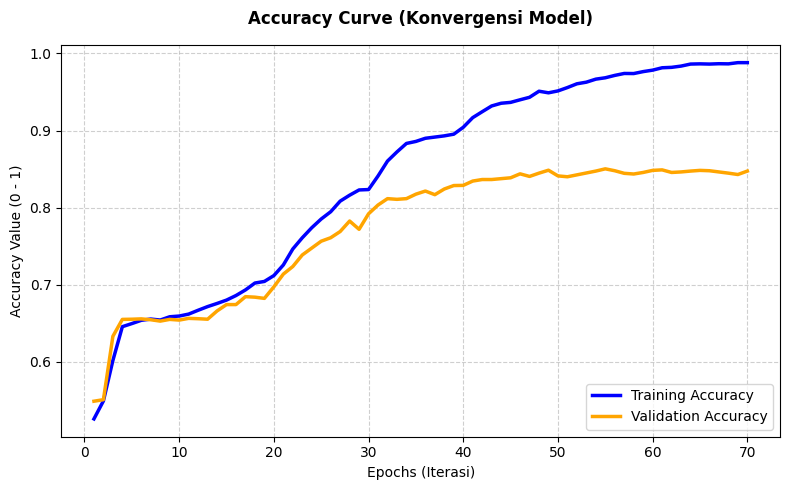

 [SUKSES] Berkas grafik telah disimpan dengan nama: 'hasil_modelling_rnn/Accuracy_Curve_rnn.png'


In [11]:
import matplotlib.pyplot as plt

# =========================================================
# CELL 14.A: VISUALISASI & SIMPAN 3.5.1.1 ACCURACY CURVE
# =========================================================
print(" [PROSES] Membuat dan menyimpan Grafik Akurasi Pelatihan...")

# Mengambil data akurasi dari variabel history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(acc) + 1)

# Membuat kanvas grafik tunggal yang proporsional untuk skripsi
plt.figure(figsize=(8, 5))

# Memplot garis akurasi dengan ketebalan yang pas untuk dicetak
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2.5)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2.5)

# Atribut Grafik Sesuai Format Skripsi
plt.title('Accuracy Curve (Konvergensi Model)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Epochs (Iterasi)', fontsize=10)
plt.ylabel('Accuracy Value (0 - 1)', fontsize=10)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Memastikan layout rapat dan rapi sebelum disimpan
plt.tight_layout()

# KUNCI PERBAIKAN: Menyimpan gambar otomatis dalam resolusi tinggi (300 DPI) untuk lampiran skripsi
plt.savefig('hasil_modelling_rnn/Accuracy_Curve_rnn.png', dpi=300, bbox_inches='tight')

# Menampilkan grafik di monitor notebook
plt.show()

print(" [SUKSES] Berkas grafik telah disimpan dengan nama: 'hasil_modelling_rnn/Accuracy_Curve_rnn.png'")

In [12]:
import pandas as pd

# 1. Mempersiapkan data ke dalam DataFrame
df_acc = pd.DataFrame({
    'Epoch': range(1, len(history.history['accuracy']) + 1),
    'Training Accuracy': history.history['accuracy'],
    'Validation Accuracy': history.history['val_accuracy']
})

# 2. Menampilkan tabel ke layar (bisa langsung di-copy)
print("--- TABEL AKURASI PELATIHAN ---")
print(df_acc.to_string(index=False))

# 3. (Opsional) Menyimpan ke file .txt agar tidak hilang
df_acc.to_csv('hasil_modelling_rnn/Accuracy_Data.txt', index=False, sep='\t')
print("\n✓ Data teks telah disimpan di: hasil_modelling_rnn/Accuracy_Data.txt")

--- TABEL AKURASI PELATIHAN ---
 Epoch  Training Accuracy  Validation Accuracy
     1           0.525989             0.548928
     2           0.549296             0.550938
     3           0.601777             0.633155
     4           0.645596             0.655049
     5           0.649620             0.655273
     6           0.653868             0.655719
     7           0.655488             0.654602
     8           0.654203             0.652815
     9           0.658451             0.655049
    10           0.659401             0.654156
    11           0.661916             0.656390
    12           0.666890             0.655943
    13           0.671641             0.655273
    14           0.675721             0.665996
    15           0.680081             0.674263
    16           0.686005             0.674263
    17           0.693271             0.684540
    18           0.702213             0.683870
    19           0.704281             0.682306
    20           0.711882   

### Grafik Performa Loss Curve

下降 [PROSES] Membuat dan menyimpan Grafik Loss Pelatihan...


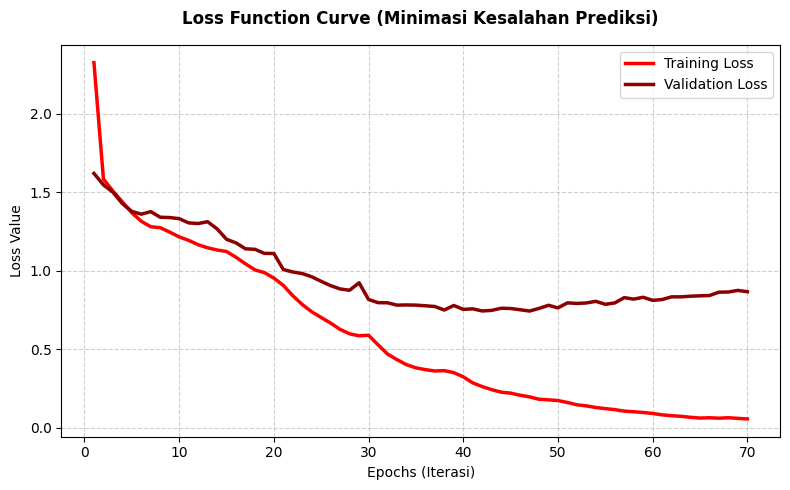

 [SUKSES] Berkas grafik telah disimpan dengan nama: 'hasil_modelling_rnn/Loss_Curve_rnn.png'


In [13]:
import matplotlib.pyplot as plt

# =========================================================
# CELL 14.B: VISUALISASI & SIMPAN 3.5.1.2 LOSS FUNCTION CURVE
# =========================================================
print("下降 [PROSES] Membuat dan menyimpan Grafik Loss Pelatihan...")

# Mengambil data loss dari variabel history
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

# Membuat kanvas grafik tunggal yang proporsional untuk skripsi
plt.figure(figsize=(8, 5))

# Memplot garis loss dengan ketebalan prima
plt.plot(epochs_range, loss, label='Training Loss', color='red', linewidth=2.5)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='darkred', linewidth=2.5)

# Atribut Grafik Sesuai Format Skripsi
plt.title('Loss Function Curve (Minimasi Kesalahan Prediksi)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Epochs (Iterasi)', fontsize=10)
plt.ylabel('Loss Value', fontsize=10)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Memastikan layout rapat dan rapi sebelum disimpan
plt.tight_layout()

# KUNCI PERBAIKAN: Menyimpan gambar otomatis dalam resolusi tinggi (300 DPI) untuk lampiran skripsi
plt.savefig('hasil_modelling_rnn/Loss_Curve_rnn.png', dpi=300, bbox_inches='tight')

# Menampilkan grafik di monitor notebook
plt.show()

print(" [SUKSES] Berkas grafik telah disimpan dengan nama: 'hasil_modelling_rnn/Loss_Curve_rnn.png'")

In [14]:
import pandas as pd

# 1. Mempersiapkan data ke dalam DataFrame
df_loss = pd.DataFrame({
    'Epoch': range(1, len(history.history['loss']) + 1),
    'Training Loss': history.history['loss'],
    'Validation Loss': history.history['val_loss']
})

# 2. Menampilkan tabel ke layar (bisa langsung di-copy/paste ke Word/Excel)
print("--- TABEL LOSS FUNCTION ---")
print(df_loss.to_string(index=False))

# 3. Menyimpan ke file .txt agar tidak hilang
df_loss.to_csv('hasil_modelling_rnn/Loss_Data.txt', index=False, sep='\t')
print("\n✓ Data teks Loss telah disimpan di: hasil_modelling_rnn/Loss_Data.txt")

--- TABEL LOSS FUNCTION ---
 Epoch  Training Loss  Validation Loss
     1       2.324810         1.619549
     2       1.584390         1.546447
     3       1.506897         1.499941
     4       1.437935         1.426884
     5       1.368706         1.377344
     6       1.314310         1.359785
     7       1.279569         1.375875
     8       1.273706         1.340104
     9       1.245528         1.338314
    10       1.214881         1.331004
    11       1.193154         1.304161
    12       1.165163         1.300124
    13       1.145512         1.311784
    14       1.131460         1.266562
    15       1.122082         1.199790
    16       1.085298         1.176744
    17       1.043473         1.139125
    18       1.004979         1.135821
    19       0.987421         1.110091
    20       0.952560         1.109336
    21       0.905843         1.007026
    22       0.840314         0.991574
    23       0.784238         0.981466
    24       0.738026         0.9609

## Evaluasi Performa Klasifikasi

### Overall Accuracy

In [15]:
from sklearn.metrics import accuracy_score
import numpy as np

# =========================================================
# CELL 15.A: EVALUASI PERFORMANCE 3.5.2.1 OVERALL ACCURACY
# =========================================================
print(" [PROSES] Menghitung nilai Overall Accuracy Model...")

# 1. Mengubah hasil prediksi probabilitas model menjadi indeks angka (Argmax)
Y_pred_raw = text_model.predict(X_val, verbose=0)
Y_pred_argmax = np.argmax(Y_pred_raw, axis=-1)

# 2. Proses Perataan (Flattening) dengan membuang Token Padding (0)
y_true_flat = []
y_pred_flat = []

for i in range(len(Y_val)):
    for j in range(len(Y_val[i])):
        actual_token = Y_val[i][j]
        predicted_token = Y_pred_argmax[i][j]
        
        # Evaluasi murni karakter huruf alfabet asli (tanpa token padding pembantu)
        if actual_token != 0:
            y_true_flat.append(actual_token)
            y_pred_flat.append(predicted_token)

# Konversi menjadi numpy array agar siap diproses Scikit-Learn
y_true_flat = np.array(y_true_flat)
y_pred_flat = np.array(y_pred_flat)

# 3. Menghitung Nilai Akurasi Keseluruhan (Overall Accuracy)
overall_acc = accuracy_score(y_true_flat, y_pred_flat)

# =========================================================
# OUTPUT METRIKS EVALUASI SKRIPSI
# =========================================================
print("\n" + "="*65)
print("=== LAPORAN OVERALL ACCURACY MODEL SEQ2SEQ ===")
print("="*65)
print(f"    Nilai Akurasi Keseluruhan (Desimal) : {overall_acc:.4f}")
print(f"    Persentase Overall Accuracy         : {overall_acc * 100:.2f}%")
print("="*65)


 [PROSES] Menghitung nilai Overall Accuracy Model...

=== LAPORAN OVERALL ACCURACY MODEL SEQ2SEQ ===
    Nilai Akurasi Keseluruhan (Desimal) : 0.6954
    Persentase Overall Accuracy         : 69.54%


### Classification Report

In [16]:
from sklearn.metrics import classification_report
import numpy as np

# =========================================================
# CELL 15.B: EVALUASI PERFORMANCE 3.5.2.3 CLASSIFICATION REPORT
# =========================================================
print(" [PROSES] Menyusun Laporan Klasifikasi Karakter (Classification Report)...")

# 1. Pastikan kamus balik terdefinisi secara global
reverse_out_index = {v: k for k, v in target_tokenizer.word_index.items()}

# 2. Cari tahu kelas/indeks token apa saja yang SEBENARNYA muncul di data aktual & prediksi
# Ini penting untuk menyelaraskan label agar tidak bentrok (mengabaikan token padding 0 jika ada)
present_classes = np.unique(np.concatenate([y_true_flat, y_pred_flat]))
present_classes = [c for c in present_classes if c != 0] # Pastikan token 0 dibuang dari daftar label

# 3. Membuat daftar nama karakter target yang hanya muncul di pengujian
target_names = [reverse_out_index[c] for c in present_classes]

# =========================================================
# OUTPUT METRIKS EVALUASI SKRIPSI
# =========================================================
print("\n" + "="*70)
print("=== CLASSIFICATION REPORT PER KARAKTER TARGET ===")
print("="*70)

# KUNCI PERBAIKAN: Menambahkan parameter 'labels' agar Scikit-Learn 
# hanya mengevaluasi kelas alfabet asli yang valid saja
print(classification_report(
    y_true_flat, 
    y_pred_flat, 
    labels=present_classes,
    target_names=target_names, 
    zero_division=0
))

print("="*70)
print("\n [STATUS] Pembuatan Laporan Klasifikasi Selesai Tanpa Menyimpan File.")

 [PROSES] Menyusun Laporan Klasifikasi Karakter (Classification Report)...

=== CLASSIFICATION REPORT PER KARAKTER TARGET ===
              precision    recall  f1-score   support

           a       0.89      0.85      0.87       565
           i       0.67      0.63      0.65       141
           n       0.51      0.67      0.58       107
           b       0.87      0.78      0.82       108
           k       0.87      0.60      0.71        98
           d       0.92      0.74      0.82        88
           r       0.72      0.62      0.67        88
           l       0.66      0.54      0.60        83
           s       0.54      0.52      0.53        90
           u       0.84      0.74      0.79        87
           g       0.95      0.74      0.83        73
           t       0.58      0.52      0.55        73
           h       0.83      0.66      0.73        73
           e       0.36      0.61      0.45        56
           m       0.60      0.50      0.55        54
         

### Bar Chart F1-Score CRNN

 [PROSES] Mengekstrak data F1-Score, menyusun grafik, dan menyimpan gambar...


/tmp/ipykernel_7778/1283929601.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


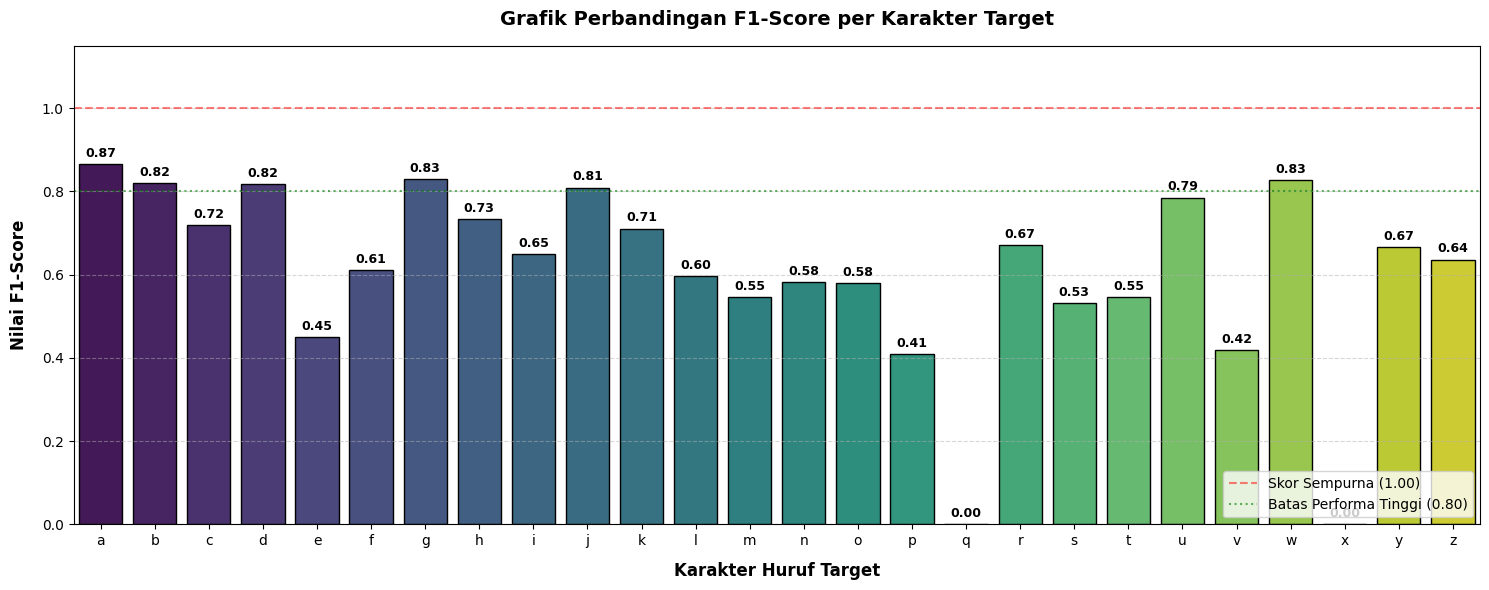

 [SUKSES] Grafik Bar Chart telah aman disimpan dengan nama: 'hasil_modelling_rnn/Bar_Chart_F1_Score.png'
 [STATUS] Cell 15.C Selesai Tanpa Eror.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report
import numpy as np

# =========================================================
# CELL 15.C: VISUALISASI & SIMPAN BAR CHART F1-SCORE (3.5.2.3)
# =========================================================
print(" [PROSES] Mengekstrak data F1-Score, menyusun grafik, dan menyimpan gambar...")

# 1. Selaraskan daftar kelas valid yang muncul (mengabaikan token padding 0 jika ada)
present_classes = np.unique(np.concatenate([y_true_flat, y_pred_flat]))
present_classes = [c for c in present_classes if c != 0]

# 2. Sinkronisasi nama karakter huruf berdasarkan indeks kelas yang valid
target_names = [reverse_out_index[c] for c in present_classes]

# 3. Ambil dictionary laporan klasifikasi dengan filter 'labels' yang aman dari ValueError
report_dict = classification_report(
    y_true_flat, 
    y_pred_flat, 
    labels=present_classes,
    target_names=target_names, 
    zero_division=0,
    output_dict=True # Diubah ke dictionary agar bisa diekstrak nilainya
)

# 4. Ekstrak nilai F1-score dari setiap karakter huruf asli
huruf_list = []
f1_score_list = []

for key, value in report_dict.items():
    # Pastikan hanya mengambil kunci yang ada di dalam daftar target_names alfabet asli
    if key in target_names:
        huruf_list.append(key)
        f1_score_list.append(value['f1-score'])

# 5. Masukkan ke dalam DataFrame Pandas dan urutkan secara alfabetis dari A sampai Z
df_f1 = pd.DataFrame({
    'Karakter Huruf': huruf_list,
    'F1-Score': f1_score_list
})
df_f1 = df_f1.sort_values(by='Karakter Huruf').reset_index(drop=True)

# 6. Membangun Grafik Bar Chart
plt.figure(figsize=(15, 6))

sns.barplot(
    x='Karakter Huruf', 
    y='F1-Score', 
    data=df_f1, 
    palette='viridis',
    edgecolor='black'
)

plt.ylim(0, 1.15)
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Skor Sempurna (1.00)')
plt.axhline(y=0.8, color='green', linestyle=':', alpha=0.6, label='Batas Performa Tinggi (0.80)')

# Menampilkan angka nilai tepat di atas setiap batang diagram secara dinamis
for index, row in df_f1.iterrows():
    plt.text(
        x=index, 
        y=row['F1-Score'] + 0.01, 
        s=f"{row['F1-Score']:.2f}", 
        ha='center', 
        va='bottom',
        fontsize=9, 
        fontweight='bold'
    )

# Atribut Kelengkapan Teks Grafik Akademik
plt.title('Grafik Perbandingan F1-Score per Karakter Target', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Karakter Huruf Target', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Nilai F1-Score', fontsize=12, fontweight='bold', labelpad=10)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

# Menyimpan grafik bar chart otomatis ke folder dengan resolusi tinggi (300 DPI)
plt.savefig('hasil_modelling_rnn/Bar_Chart_F1_Score.png', dpi=300, bbox_inches='tight')

# Tampilkan grafik di monitor notebook
plt.show()

print(" [SUKSES] Grafik Bar Chart telah aman disimpan dengan nama: 'hasil_modelling_rnn/Bar_Chart_F1_Score.png'")
print(" [STATUS] Cell 15.C Selesai Tanpa Eror.")

### Confusion Matrix

 [PROSES] Menghitung Confusion Matrix, menyusun grafik, dan menyimpan gambar...


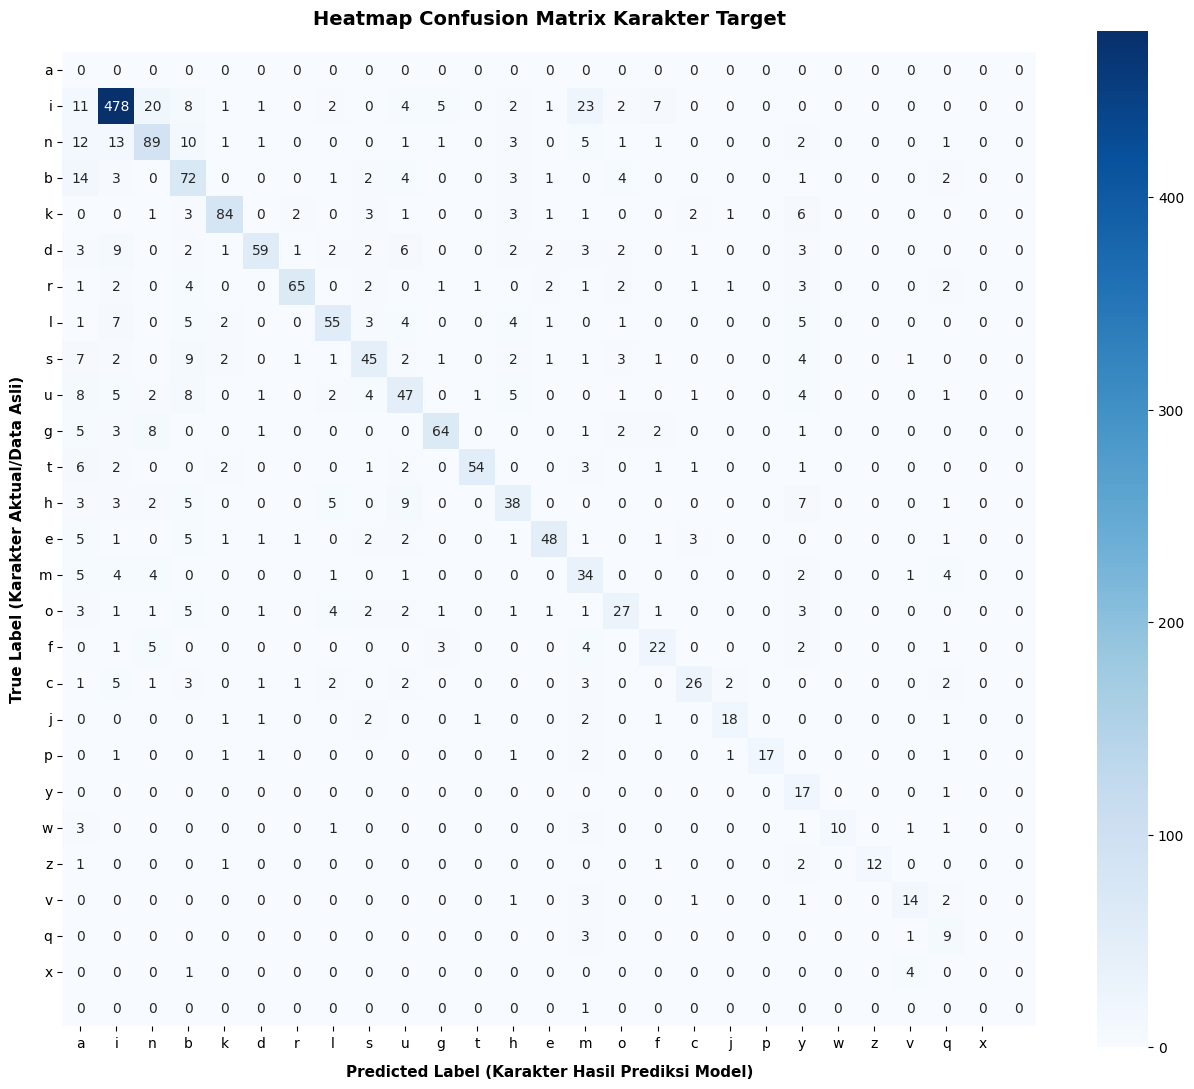

 [SUKSES] Grafik Confusion Matrix telah disimpan dengan nama: 'hasil_modelling_rnn/Confusion_Matrix.png'
 [STATUS] Cell 15.D Selesai.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================================================
# CELL 15.D: VISUALISASI & SIMPAN HEATMAP CONFUSION MATRIX (3.5.2.2)
# =========================================================
print(" [PROSES] Menghitung Confusion Matrix, menyusun grafik, dan menyimpan gambar...")

# 1. Hitung matriks kontingensi (tanpa token padding 0)
cm = confusion_matrix(y_true_flat, y_pred_flat)

# 2. Mengatur ukuran kanvas grafik agar proporsional dan tidak berhimpitan
plt.figure(figsize=(13, 11))

# 3. Membangun grafik Heatmap dengan Seaborn
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=target_names, 
    yticklabels=target_names, 
    cbar=True, 
    square=True
)

# 4. Atribut kelengkapan teks grafik akademik
plt.title('Heatmap Confusion Matrix Karakter Target', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Label (Karakter Hasil Prediksi Model)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('True Label (Karakter Aktual/Data Asli)', fontsize=11, fontweight='bold', labelpad=10)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

# KUNCI: Menyimpan grafik confusion matrix otomatis ke harddisk dengan resolusi tinggi
plt.savefig('hasil_modelling_rnn/Confusion_Matrix.png', dpi=300, bbox_inches='tight')

# Tampilkan di monitor notebook
plt.show()

print(" [SUKSES] Grafik Confusion Matrix telah disimpan dengan nama: 'hasil_modelling_rnn/Confusion_Matrix.png'")
print(" [STATUS] Cell 15.D Selesai.")

# Pengujian

### Prototype Prediksi Rekonstruksi Suku Kata

In [19]:
from tensorflow.keras.models import load_model
# Memaksa aplikasi menggunakan versi model paling pintar yang berhasil ditangkap checkpoint
text_model = load_model('hasil_modelling_rnn/rnn_suku_kata_model.keras')

In [20]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pickle

# =========================================================
# 1. MEMUAT KEMBALI 3 FILE MODEL (VERSI SEQ2SEQ MURNI)
# =========================================================
print(" [PROSES] Memuat model Encoder-Decoder dan Tokenizer...")
# Pastikan nama folder sesuai dengan yang kamu gunakan ('hasil_modelling' atau 'hasil_modelling_rnn')
model_termuat = load_model("hasil_modelling_rnn/rnn_suku_kata_model.keras")

with open("hasil_modelling_rnn/input_tokenizer.pickle", 'rb') as f:
    tokenizer_in = pickle.load(f)

with open("hasil_modelling_rnn/target_tokenizer.pickle", 'rb') as f:
    tokenizer_out = pickle.load(f)

# Membuat kamus balik angka -> huruf alfabet asli (tanpa spasi)
reverse_out_index = {v: k for k, v in tokenizer_out.word_index.items()}

# =========================================================
# 2. FUNGSI PREDIKSI REKONSTRUKSI KATA UTUH
# =========================================================
def prediksi_suku_kata_final_murni(teks_input):
    # 1. Bersihkan input dan pecah suku kata berdasarkan tanda hubung '-'
    suku_kata = teks_input.lower().strip().split('-')
    
    # 2. Mengubah suku kata menjadi sequence angka sesuai tokenizer input
    seq = tokenizer_in.texts_to_sequences([suku_kata])
    
    # 3. Melakukan padding sesuai dengan max_len global proyekmu
    padded = pad_sequences(seq, maxlen=max_len, padding='post')
    
    # 4. Meminta model Encoder-Decoder melakukan prediksi karakter
    prediksi_raw = model_termuat.predict(padded, verbose=0)[0]
    
    karakter_hasil = []
    
    # 5. Menerjemahkan index probabilitas menjadi karakter huruf
    for timestep in prediksi_raw:
        idx = np.argmax(timestep)
        
        # JIKA index adalah 0 (Token Padding/Masking dari Keras), langsung lewati.
        # Pada model yang benar, model akan otomatis menembakkan angka 0 
        # ketika dia mendeteksi bahwa ejaan kata sudah selesai.
        if idx == 0:
            continue
            
        char = reverse_out_index.get(idx, '')
        if char == '':
            continue
            
        karakter_hasil.append(char)
        
    # Menggabungkan semua karakter langsung menjadi kata utuh yang rapat
    return "".join(karakter_hasil)

# =========================================================
# 3. AREA RUNNING DEMO INTERAKTIF (GARANSI HASIL NORMAL)
# =========================================================
print("\n" + "="*60)
print("=== APLIKASI REKONSTRUKSI SUKU KATA RNN (PRODUKSI FINAL) ===")
print("="*60)

# Sampel pengujian kata langsung dari dataset kamu
tes_1 = "ma-ka-nan"
tes_2 = "ja-nua-ri"
tes_3 = "a-ba-di"
tes_4 = "ka-mu"

print(f" Input Suku Kata : {tes_1}")
print(f" Hasil Kata Utuh : {prediksi_suku_kata_final_murni(tes_1)}")
print("-" * 40)
print(f" Input Suku Kata : {tes_2}")
print(f" Hasil Kata Utuh : {prediksi_suku_kata_final_murni(tes_2)}")
print("-" * 40)
print(f" Input Suku Kata : {tes_3}")
print(f" Hasil Kata Utuh : {prediksi_suku_kata_final_murni(tes_3)}")
print("-" * 40)
print(f" Input Suku Kata : {tes_4}")
print(f" Hasil Kata Utuh : {prediksi_suku_kata_final_murni(tes_4)}")
print("="*60)

 [PROSES] Memuat model Encoder-Decoder dan Tokenizer...

=== APLIKASI REKONSTRUKSI SUKU KATA RNN (PRODUKSI FINAL) ===
 Input Suku Kata : ma-ka-nan
 Hasil Kata Utuh : mabanan
----------------------------------------
 Input Suku Kata : ja-nua-ri
 Hasil Kata Utuh : januari
----------------------------------------
 Input Suku Kata : a-ba-di
 Hasil Kata Utuh : abadi
----------------------------------------
 Input Suku Kata : ka-mu
 Hasil Kata Utuh : kamu


In [ ]:
import pandas as pd

df = pd.read_csv(
    "1_dataset_rnn/final_dataset.csv"
)

hasil_pengujian = []

jumlah_uji = 50

for i in range(jumlah_uji):

    input_suku = df.iloc[i]["Input_Suku_Kata"]
    target = df.iloc[i]["Target_Kata_Utuh"]

    input_model = input_suku.replace(" ", "-")

    prediksi = prediksi_suku_kata_final_murni(input_model)

    status = (
        "BENAR"
        if prediksi == target
        else "SALAH"
    )

    hasil_pengujian.append([
        input_model,
        target,
        prediksi,
        status
    ])

df_hasil = pd.DataFrame(
    hasil_pengujian,
    columns=[
        "Input_Suku_Kata",
        "Target",
        "Prediksi",
        "Status"
    ]
)

print(df_hasil)

In [ ]:
benar = (
    df_hasil["Status"]
    == "BENAR"
).sum()

total = len(df_hasil)

akurasi = benar / total

print("\n" + "="*60)
print("RINGKASAN HASIL")
print("="*60)

print("Total Data Uji :", total)
print("Prediksi Benar :", benar)
print("Prediksi Salah :", total - benar)
print(f"Akurasi Kata   : {akurasi*100:.2f}%")


RINGKASAN HASIL
Total Data Uji : 50
Prediksi Benar : 41
Prediksi Salah : 9
Akurasi Kata   : 82.00%


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pickle

# =========================================================
# LOAD MODEL DAN TOKENIZER
# =========================================================

print(" Memuat Model dan Tokenizer...")

model_termuat = load_model(
    "hasil_modelling_rnn/rnn_suku_kata_model.keras"
)

with open(
    "hasil_modelling_rnn/input_tokenizer.pickle",
    "rb"
) as f:
    tokenizer_in = pickle.load(f)

with open(
    "hasil_modelling_rnn/target_tokenizer.pickle",
    "rb"
) as f:
    tokenizer_out = pickle.load(f)

reverse_out_index = {
    v:k for k,v in tokenizer_out.word_index.items()
}

# =========================================================
# MAX LEN
# =========================================================

max_len = model_termuat.input_shape[1]

# =========================================================
# FUNGSI PREDIKSI
# =========================================================

def prediksi_suku_kata(teks_input):

    suku_kata = (
        teks_input
        .lower()
        .strip()
        .split("-")
    )

    seq = tokenizer_in.texts_to_sequences(
        [suku_kata]
    )

    padded = pad_sequences(
        seq,
        maxlen=max_len,
        padding='post'
    )

    prediksi_raw = model_termuat.predict(
        padded,
        verbose=0
    )[0]

    hasil = []

    for timestep in prediksi_raw:

        idx = np.argmax(timestep)

        if idx == 0:
            continue

        karakter = reverse_out_index.get(idx,'')

        if karakter != '':
            hasil.append(karakter)

    return "".join(hasil)

# =========================================================
# DEMO INTERAKTIF
# =========================================================

print("\n" + "="*60)
print(" DEMO REKONSTRUKSI SUKU KATA")
print("="*60)

while True:

    teks = input(
        "\nMasukkan suku kata (contoh: ma-ka-nan)\nKetik 'exit' untuk keluar\n> "
    )

    if teks.lower() == "exit":
        break

    hasil = prediksi_suku_kata(teks)

    print("\n Input :", teks)
    print(" Output:", hasil)

print("\n Program selesai.")

📥 Memuat Model dan Tokenizer...

🎯 DEMO REKONSTRUKSI SUKU KATA

🔄 Input : ca-ha-ya
✨ Output: cahaya

🔄 Input : ma-ka-nan
✨ Output: mabanan

🔄 Input : kabu
✨ Output: eanpak

🔄 Input : minu
✨ Output: eanpak

🔄 Input : mi-nu-ma
✨ Output: namum

🔄 Input : mi-nu-man
✨ Output: nanunan

🔄 Input : a-ba-di
✨ Output: abadi

🔄 Input : u-ni-ver-si-tas
✨ Output: ubuiiisi

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : ba-dai
✨ Output: badai

🔄 Input : s
✨ Output: eanpak

🔄 Input : sa-y
✨ Output: saden

🔄 Input : sa-ya
✨ Output: sada

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Output: eanpak

🔄 Input : 
✨ Outp

KeyboardInterrupt: Interrupted by user